In [1]:
# dependencies
import os, math, time, random
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
%matplotlib inline
 
import cv2
from glob import glob
import tensorflow as tf
from sklearn.utils import shuffle

 # skimage
from skimage.io import imread 
from skimage import io
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage import data, color

# pil
from PIL import Image as pil_image

import warnings
warnings.filterwarnings("ignore")

# from keras
import keras
from keras.utils import np_utils
from keras import optimizers
from keras.models import Sequential
from keras.layers import  MaxPooling2D, BatchNormalization, Flatten
from keras.layers import Input, Conv2D, Activation,  MaxPool2D, AveragePooling2D
from keras.layers import GlobalAveragePooling2D, Dense, Dropout, GlobalMaxPooling2D
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.layers.merge import add
from keras.activations import relu, sigmoid
from keras import regularizers
from keras.preprocessing.image import ImageDataGenerator
from keras.applications.nasnet import NASNetMobile
from keras.layers import Concatenate
from keras.models import Model
from keras.optimizers import Adam
#from keras.applications.resnet import ResNet101

# scikit learn helper functions
from sklearn.model_selection import train_test_split


2026-01-07 04:07:23.926429: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767758843.939376      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767758843.943471      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-07 04:07:23.959781: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

ImportError: cannot import name 'np_utils' from 'keras.utils' (/usr/local/lib/python3.11/dist-packages/keras/api/utils/__init__.py)

In [2]:
IMG_SIZE = 32 # in the given original size


In [3]:
print('Given files: ', os.listdir('../input/'))
# data shapes
print('train images: ', len(os.listdir('../input/train/train')))
print('test images: ', len(os.listdir('../input/test/test')))


Given files:  ['sample_submission.csv', 'description.md', 'test.zip', 'train.csv', 'sample_submission.csv.zip', 'test', 'train.zip', 'aerial-cactus-identification', 'train', 'train.csv.zip']
train images:  14176
test images:  3326


In [4]:
train_folder = '../input/train/train'
test_folder = '../input/test/test'
train_df = pd.read_csv('../input/train.csv')


In [5]:
train_df.head()


,id,has_cactus
0,2de8f189f1dce439766637e75df0ee27.jpg,1
1,36704d250f236238e7f996812c48235d.jpg,1
2,eacde22fdc8c175972a5768e3daa8bc9.jpg,1
3,5d442f834da5e57d22b24802c32a8ca8.jpg,1
4,152491e0daf75c0e669400300ff7e645.jpg,1


In [6]:
train_images_path = glob('../input/train/train/*.jpg')
test_images_path = glob('../input/test/test/*.jpg')


In [7]:
# retunrs a complete path to a image with Image name
def expand_path(path):
    if os.path.isfile('../input/train/train/' + path):
        return '../input/train/train/' + path
    if os.path.isfile('../input/test/test/' + path):
        return '../input/test/test/' + path
    return path

# returns a resized black and white PIL Image object
def pil_image_load(image):
    image_path = expand_path(image)
    image = pil_image.open(image_path)#.convert('L')
    return image.resize((IMG_SIZE, IMG_SIZE))
    #return image


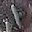

In [8]:
pil_image_load(expand_path(train_images_path[10]))


In [9]:
train_df.head()


,id,has_cactus
0,2de8f189f1dce439766637e75df0ee27.jpg,1
1,36704d250f236238e7f996812c48235d.jpg,1
2,eacde22fdc8c175972a5768e3daa8bc9.jpg,1
3,5d442f834da5e57d22b24802c32a8ca8.jpg,1
4,152491e0daf75c0e669400300ff7e645.jpg,1


In [10]:
# retunrs a complete path to a image with Image name
def expand_path(path):
    if os.path.isfile('../input/train/train/' + path):
        return '../input/train/train/' + path
    if os.path.isfile('../input/test/test/' + path):
        return '../input/test/test/' + path
    return path

# load the resized image
def read_image(img_path, resized_shape=None):
    # expanding img_path to complete image path
    img_path = expand_path(img_path)
    image = imread(img_path)
    gray_image = color.rgb2gray(image)
    rgb_image = color.gray2rgb(gray_image)
    if resized_shape:
        image_resized = resize(rgb_image,(resized_shape,resized_shape, 3))
        return image_resized[:,:]/255
    return rgb_image[:,:]/255


In [11]:
train_df.head()


,id,has_cactus
0,2de8f189f1dce439766637e75df0ee27.jpg,1
1,36704d250f236238e7f996812c48235d.jpg,1
2,eacde22fdc8c175972a5768e3daa8bc9.jpg,1
3,5d442f834da5e57d22b24802c32a8ca8.jpg,1
4,152491e0daf75c0e669400300ff7e645.jpg,1


In [12]:
# train data dataframe
train_df['image'] = train_df['id'].apply(lambda path: read_image(path))


In [13]:
# creating test dataframe
test_df = pd.DataFrame(columns=["id", "image"])
test_df['id'] = os.listdir('../input/test/test/')
test_df['image'] = test_df['id'].apply(lambda path: read_image(path))


FileNotFoundError: No such file: '/kaggle/working/test'

In [14]:
test_df.head()


,id,image
0,76bad42ebc1ed65f7f50c06fd17849db.jpg,NaN
1,f620bd2745d51c25cd05eca4f7c4da94.jpg,NaN
2,0e47e71ea2829d6d88944482ada145a5.jpg,NaN
3,d66598ea219072e9c0b98e1a162cc8f6.jpg,NaN
4,3288a35f07e97293155203bec36c0a8d.jpg,NaN


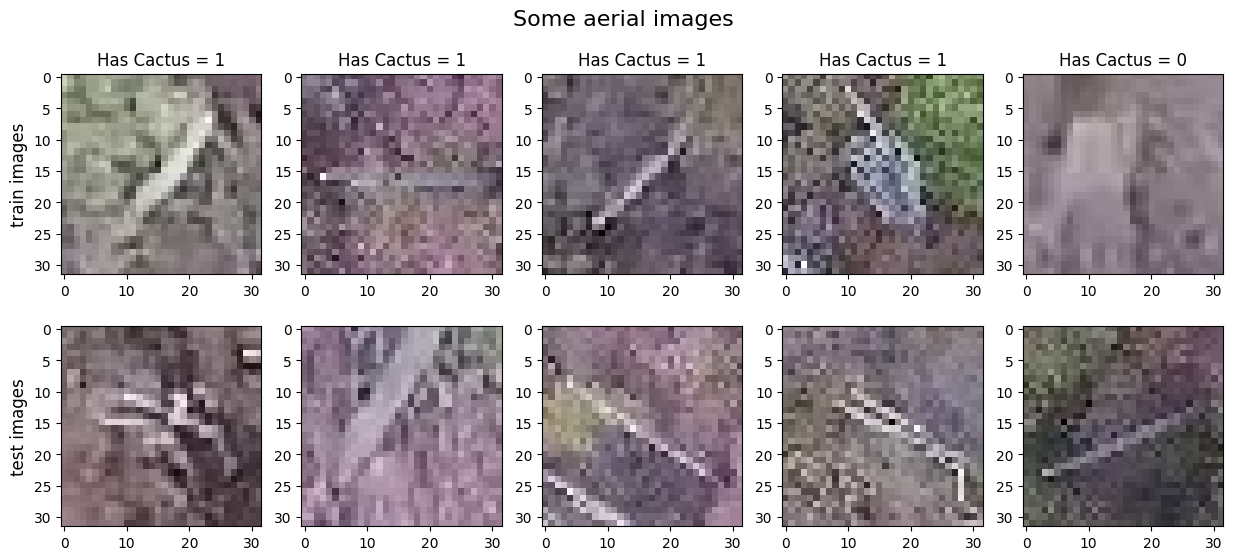

In [15]:
random.shuffle(train_images_path)
fig, ax = plt.subplots(2,5, figsize=(15,6))
fig.suptitle('Some aerial images',fontsize=16)

df = shuffle(train_df)
for i, item in enumerate(df.values[15:20]):
    image = pil_image.open(expand_path(item[0]))
    ax[0,i].imshow(image)
    ax[0, i].set_title('Has Cactus = %d' % (item[1]))
ax[0,0].set_ylabel('train images', size='large')

for i, path in enumerate(test_images_path[:5]):
    image = pil_image.open(path)
    #image = image.resize((IMG_SIZE, IMG_SIZE))
    ax[1,i].imshow(image)
ax[1,0].set_ylabel('test images', size='large');


In [16]:
# CNN model
def CNN():
    model = Sequential()
    model.add(Conv2D(256, (3, 3), strides = (1, 1), input_shape = (IMG_SIZE, IMG_SIZE, 3)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))
    
    model.add(Conv2D(128, (3, 3), strides = (1,1)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))

    
    model.add(Conv2D(256, (3, 3), strides = (1,1)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))
    
    # fully connected layer
    model.add(Flatten())
    model.add(Dense(512,activation='relu'))
    
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=optimizers.rmsprop(), metrics=['accuracy'])
    return model


In [17]:
# returns a batch of image for training
def train_batch(train_df):
    batch_size = train_df.shape[0]
    images = train_df.image.values
    first_image = images[0]
    x_train = []
    y_train = train_df.has_cactus.values
    for i, image in enumerate(images):
        x_train.append(image.tolist())
    x_train = np.array(x_train)
    y_train = y_train.reshape(len(y_train), 1)
    return x_train, y_train


In [18]:
model = CNN()
model.summary()


NameError: name 'Sequential' is not defined

In [19]:
X_train, y_train = train_batch(train_df)


In [20]:
 # batch train (with batch load) the model with training data
def train_model(model, X_train, y_train, epochs=5, verbose=None):
    begin = time.time()
    # checkpoint
    checkpointer = ModelCheckpoint(filepath='weights.hdf5', monitor='val_acc', verbose=0, save_best_only=True)
    early_stopping = EarlyStopping(monitor='val_acc', verbose=1, patience=5)
    for i in range(1, epochs + 1):
        print('************************************')
        print('Epoch: ', i, '/', epochs)
        print('************************************')
        if verbose:
            verbose = verbose
        # fitting
        model.fit(X_train, y_train, verbose=verbose, callbacks=[checkpointer, early_stopping], validation_split=0.05)     
    # done!
    elapsed = time.time() - begin
    print('total training time: ', elapsed)
    return model


In [21]:
train_model(model, X_train, y_train, epochs=20, verbose=1);


NameError: name 'model' is not defined

In [22]:
# Test prediction data preparation
test_images = []
for image in test_df.image.values:
    test_images.append(image)
X_test = np.array(test_images)


In [23]:
# prediction on test data
y_pred = model.predict(X_test)
y_test = (y_pred.flatten() > 0.5).astype('int8')


NameError: name 'model' is not defined

In [24]:
# submission file preparation

submission=pd.DataFrame({'id':test_df['id']})
submission['has_cactus']=y_test


NameError: name 'y_test' is not defined

In [25]:
submission.head()


,id
0,76bad42ebc1ed65f7f50c06fd17849db.jpg
1,f620bd2745d51c25cd05eca4f7c4da94.jpg
2,0e47e71ea2829d6d88944482ada145a5.jpg
3,d66598ea219072e9c0b98e1a162cc8f6.jpg
4,3288a35f07e97293155203bec36c0a8d.jpg


In [26]:
submission.to_csv("submission.csv",index=False)
